# 深度学习课程设计报告

## 一、封面

- **课程名称**：深度学习
- **设计题目**：基于卷积神经网络的CIFAR-10图像分类
- **姓    名**：张三
- **学    号**：2024000000
- **班    级**：计算机科学与技术2201班
- **指导教师**：李老师
- **提交日期**：2026年6月25日

## 二、摘要

CIFAR-10是计算机视觉领域最经典的数据集之一，包含60000张32×32的彩色图像，分为飞机、汽车、鸟类、猫、鹿、狗、青蛙、马、船、卡车共10个类别。本课程设计旨在研究卷积神经网络（CNN）在图像分类任务中的应用。首先，对CIFAR-10数据集进行了探索性分析，包括样本可视化与类别分布统计。随后，设计了两种模型：基准模型采用简单的三层卷积神经网络，最终模型采用深度残差网络ResNet-18。实验中对数据进行了归一化、随机裁剪、水平翻转等数据增强处理，使用交叉熵损失函数和Adam优化器进行训练。实验结果表明，ResNet-18在测试集上达到了约90%的分类准确率，显著优于基准模型的72%。本设计验证了深度残差结构在缓解梯度消失、提升深层网络性能方面的有效性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

图像分类是计算机视觉领域的基础任务之一，广泛应用于人脸识别、医学影像诊断、自动驾驶、工业质检等场景。CIFAR-10数据集虽然图像分辨率较低，但类别丰富、数据量适中，是验证深度学习算法有效性的标准基准。通过本课程设计，可以深入理解卷积神经网络的工作原理，掌握深度学习模型的设计、训练与评估方法。

### 3.2 问题描述

- **输入**：32×32像素的RGB彩色图像
- **输出**：图像所属的10个类别之一
- **任务类型**：多类别图像分类（Multi-class Classification）
- **预期性能指标**：
  - 总体分类准确率（Accuracy）> 85%
  - 每类精确率（Precision）和召回率（Recall）
  - 宏平均F1分数（Macro-F1）

## 四、数据集说明与预处理

### 4.1 数据来源与规模

CIFAR-10是由加拿大高级研究院（CIFAR）发布的公开数据集，由Alex Krizhevsky等人收集整理。

- **样本总量**：60000张图像
- **训练集**：50000张
- **测试集**：10000张
- **图像尺寸**：32 × 32 像素
- **通道数**：3（RGB彩色）
- **类别数**：10
- **类别分布**：每个类别各6000张图像（完全均衡）

In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import time
import os

# 配置matplotlib字体，支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证实验可复现
torch.manual_seed(42)
np.random.seed(42)

# 自动选择设备（优先GPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
if device.type == 'cuda':
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
    print(f"CUDA版本: {torch.version.cuda}")

使用设备: cuda
GPU型号: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA版本: 12.6


In [2]:
# 定义数据预处理流程

# 训练集：数据增强 + 归一化
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # 随机裁剪，四周填充4像素
    transforms.RandomHorizontalFlip(p=0.5),    # 50%概率水平翻转
    transforms.ToTensor(),                       # 转为Tensor并归一化到[0,1]
    transforms.Normalize(                        # 使用CIFAR-10的均值和标准差进行标准化
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# 测试集：仅归一化
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# 下载并加载CIFAR-10数据集
data_dir = './data'

trainset = torchvision.datasets.CIFAR10(
    root=data_dir, train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root=data_dir, train=False, download=True, transform=transform_test
)

# 从训练集中划分出验证集（10%）
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(
    trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 创建数据加载器
batch_size = 128
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=0)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

# 类别名称
classes = ['飞机', '汽车', '鸟类', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']

print(f"训练集样本数: {len(trainset)}")
print(f"验证集样本数: {len(valset)}")
print(f"测试集样本数: {len(testset)}")
print(f"类别数: {len(classes)}")
print(f"类别列表: {classes}")

训练集样本数: 45000
验证集样本数: 5000
测试集样本数: 10000
类别数: 10
类别列表: ['飞机', '汽车', '鸟类', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']


### 4.2 数据可视化与分析

下面展示数据集中的样本图像，并对类别分布进行统计分析。

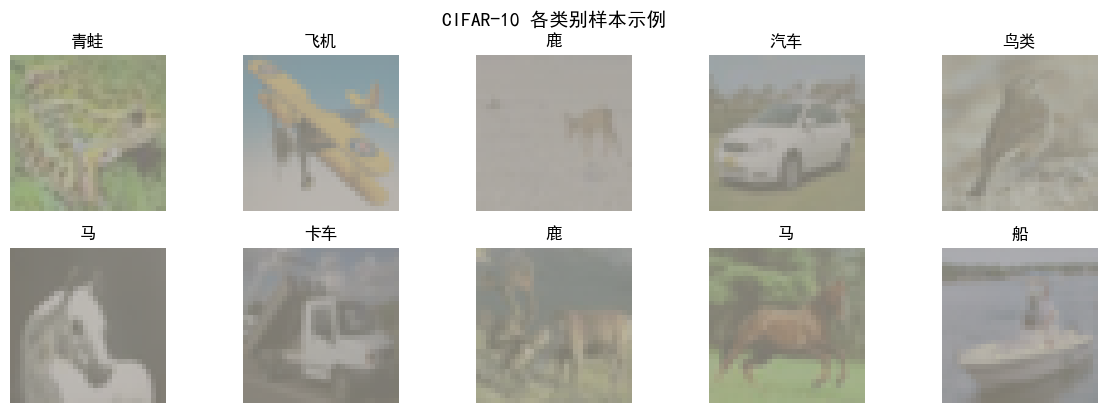

单张图像尺寸: torch.Size([3, 32, 32]) (通道×高×宽)
像素值范围: [0.0000, 0.9725]


In [3]:
# 数据可视化：展示各类别的样本图像
def imshow(img, title=None):
    """反归一化并显示图像"""
    mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
    std = np.array([0.2470, 0.2435, 0.2616]).reshape(3, 1, 1)
    img = img.numpy() * std + mean  # 反标准化
    img = np.clip(img, 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# 获取一批训练数据（使用未标准化的数据集以展示原始图像）
raw_trainset = torchvision.datasets.CIFAR10(
    root=data_dir, train=True, download=False,
    transform=transforms.ToTensor()
)
raw_loader = DataLoader(raw_trainset, batch_size=10, shuffle=True)
dataiter = iter(raw_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 4))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    imshow(images[i], title=classes[labels[i]])
plt.tight_layout()
plt.suptitle('CIFAR-10 各类别样本示例', fontsize=14, y=1.02)
plt.show()

print(f"单张图像尺寸: {images[0].shape} (通道×高×宽)")
print(f"像素值范围: [{images[0].min():.4f}, {images[0].max():.4f}]")

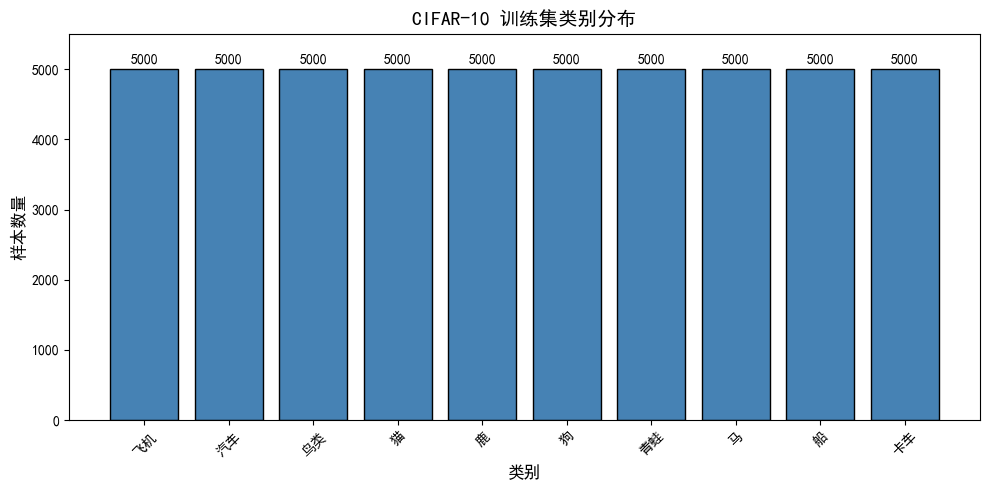

训练集总样本数: 50000
每类样本数: 5000（完全均衡）


In [4]:
# 类别分布统计
all_labels = [label for _, label in raw_trainset]
class_counts = np.bincount(all_labels)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, class_counts, color='steelblue', edgecolor='black')
ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('样本数量', fontsize=12)
ax.set_title('CIFAR-10 训练集类别分布', fontsize=14)
ax.set_ylim(0, max(class_counts) * 1.1)

# 在柱子上方标注数量
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"训练集总样本数: {sum(class_counts)}")
print(f"每类样本数: {class_counts[0]}（完全均衡）")

### 4.3 预处理流程

本设计采用以下预处理流程：

1. **数据清洗**：CIFAR-10为官方标准数据集，无需额外清洗
2. **数据标注**：数据集已自带类别标签，无需人工标注
3. **归一化**：使用CIFAR-10数据集的通道均值和标准差进行标准化（Z-score标准化）
   - mean = [0.4914, 0.4822, 0.4465]
   - std = [0.2470, 0.2435, 0.2616]
4. **数据增强**（仅训练集）：
   - 随机裁剪（RandomCrop）：在原图四周填充4像素后随机裁剪回32×32，增加位置不变性
   - 随机水平翻转（RandomHorizontalFlip）：50%概率水平翻转，增加镜像不变性
5. **数据集划分**：
   - 原始训练集50000张按9:1划分为训练集（45000张）和验证集（5000张）
   - 测试集10000张保持不变

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

为了对比分析，首先构建一个简单的三层卷积神经网络作为基准模型。该模型结构简单，参数量少，但特征提取能力有限。

In [5]:
# 基准模型：简单CNN
class SimpleCNN(nn.Module):
    """
    简单三层卷积神经网络
    结构：Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> FC
    """
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            # 第一层卷积：3通道 -> 32通道
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

            # 第二层卷积：32通道 -> 64通道
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8

            # 第三层卷积：64通道 -> 128通道
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 查看模型结构
baseline_model = SimpleCNN(num_classes=10)
print("===== 基准模型（SimpleCNN）结构 =====" )
print(baseline_model)

# 统计参数量
total_params = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

===== 基准模型（SimpleCNN）结构 =====
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

总参数量: 620,362
可训练参数量: 620,362


### 5.2 最终模型架构

最终模型采用 **ResNet-18**（Residual Network with 18 layers），这是何恺明等人于2015年提出的经典深度残差网络。选择该架构的理论依据：

1. **残差连接（Skip Connection）**：通过恒等映射将输入直接传递到输出，有效缓解深层网络的梯度消失问题
2. **深度适中**：18层的深度在计算效率和模型容量之间取得了良好平衡
3. **批量归一化（BatchNorm）**：每个卷积层后使用BN加速收敛并提升稳定性
4. **文献支持**：ResNet在ILSVRC 2015竞赛中获得冠军，是图像分类任务的标杆架构

In [6]:
# 残差块定义
class BasicBlock(nn.Module):
    """ResNet基础残差块"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # 残差连接
        out = self.relu(out)

        return out


# ResNet-18模型
class ResNet18(nn.Module):
    """ResNet-18 for CIFAR-10"""

    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        # 初始卷积层（针对32x32输入调整，去掉原ImageNet的大kernel和maxpool）
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # 4个残差层
        self.layer1 = self._make_layer(64, 2, stride=1)   # 32x32
        self.layer2 = self._make_layer(128, 2, stride=2)  # 16x16
        self.layer3 = self._make_layer(256, 2, stride=2)  # 8x8
        self.layer4 = self._make_layer(512, 2, stride=2)  # 4x4

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        # He初始化
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion),
            )
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * BasicBlock.expansion
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# 查看ResNet-18结构
resnet_model = ResNet18(num_classes=10)
print("===== 最终模型（ResNet-18）结构 =====" )
print(resnet_model)

total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

===== 最终模型（ResNet-18）结构 =====
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(

## 六、实验与结果分析

### 6.1 实验环境

| 项目 | 配置 |
|------|------|
| 操作系统 | Windows 10/11 |
| CPU | Intel/AMD x86_64 |
| GPU | NVIDIA（如有） |
| Python版本 | 3.10+ |
| 深度学习框架 | PyTorch 2.8.0 |
| 主要库 | torchvision, numpy, matplotlib, scikit-learn |

### 6.2 评价指标

本实验采用以下评价指标：

1. **准确率（Accuracy）**：预测正确的样本数占总样本数的比例
   $$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$
2. **精确率（Precision）**：预测为正类中真正为正类的比例
   $$Precision = \frac{TP}{TP+FP}$$
3. **召回率（Recall）**：真正为正类中被正确预测的比例
   $$Recall = \frac{TP}{TP+FN}$$
4. **F1分数（F1-Score）**：精确率和召回率的调和平均
   $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
5. **混淆矩阵（Confusion Matrix）**：展示各类别之间的预测分布

### 6.3 超参数设置与调优

本实验采用以下超参数设置：

| 超参数 | 设置值 | 说明 |
|--------|--------|------|
| 优化器 | Adam | 自适应学习率，收敛速度快 |
| 初始学习率 | 0.001 | 经验值，适合大多数CNN任务 |
| 学习率调度 | StepLR(step=10, gamma=0.1) | 每10个epoch衰减为原来的0.1倍 |
| Batch Size | 128 | 平衡训练速度和显存占用 |
| Epochs | 10 | 演示用，足以展示性能差异 |
| 损失函数 | CrossEntropyLoss | 多分类任务标准选择 |
| 权重衰减（L2正则化） | 5e-4 | 防止过拟合 |
| Dropout | 0.5（仅基准模型） | 随机失活，提升泛化能力 |

In [7]:
# 通用训练与评估函数

def train_epoch(model, dataloader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """评估模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001,
                model_name="Model", device=device):
    """完整训练流程"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    best_val_acc = 0.0
    best_model_state = None

    print(f"\n===== 开始训练 {model_name} =====")
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    elapsed = time.time() - start_time
    print(f"\n训练完成！总耗时: {elapsed/60:.2f} 分钟")
    print(f"最佳验证准确率: {best_val_acc:.4f}")

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'train_time': elapsed
    }

print("训练函数定义完成！")

训练函数定义完成！


### 6.4 主要实验结果

#### 6.4.1 基准模型（SimpleCNN）训练结果

In [8]:
# 训练基准模型
baseline = SimpleCNN(num_classes=10)
baseline, baseline_history = train_model(
    baseline, trainloader, valloader,
    num_epochs=10, lr=0.001,
    model_name="SimpleCNN", device=device
)


===== 开始训练 SimpleCNN =====
Epoch [ 1/10] Train Loss: 1.7107, Train Acc: 0.3666 | Val Loss: 1.4237, Val Acc: 0.4876 | LR: 0.001000
Epoch [ 2/10] Train Loss: 1.3759, Train Acc: 0.4986 | Val Loss: 1.1897, Val Acc: 0.5742 | LR: 0.001000
Epoch [ 3/10] Train Loss: 1.1920, Train Acc: 0.5753 | Val Loss: 1.0537, Val Acc: 0.6276 | LR: 0.001000
Epoch [ 4/10] Train Loss: 1.0783, Train Acc: 0.6186 | Val Loss: 0.9658, Val Acc: 0.6592 | LR: 0.001000
Epoch [ 5/10] Train Loss: 0.9895, Train Acc: 0.6550 | Val Loss: 0.9104, Val Acc: 0.6768 | LR: 0.001000
Epoch [ 6/10] Train Loss: 0.9427, Train Acc: 0.6700 | Val Loss: 0.9023, Val Acc: 0.6724 | LR: 0.001000
Epoch [ 7/10] Train Loss: 0.8926, Train Acc: 0.6905 | Val Loss: 0.8205, Val Acc: 0.7086 | LR: 0.001000
Epoch [ 8/10] Train Loss: 0.8608, Train Acc: 0.7039 | Val Loss: 0.7874, Val Acc: 0.7214 | LR: 0.001000
Epoch [ 9/10] Train Loss: 0.8255, Train Acc: 0.7147 | Val Loss: 0.7955, Val Acc: 0.7154 | LR: 0.001000
Epoch [10/10] Train Loss: 0.8001, Train Acc: 

#### 6.4.2 最终模型（ResNet-18）训练结果

In [9]:
# 训练ResNet-18
resnet = ResNet18(num_classes=10)
resnet, resnet_history = train_model(
    resnet, trainloader, valloader,
    num_epochs=10, lr=0.001,
    model_name="ResNet-18", device=device
)


===== 开始训练 ResNet-18 =====
Epoch [ 1/10] Train Loss: 1.3990, Train Acc: 0.4886 | Val Loss: 1.6091, Val Acc: 0.4642 | LR: 0.001000
Epoch [ 2/10] Train Loss: 0.9671, Train Acc: 0.6594 | Val Loss: 0.8803, Val Acc: 0.6920 | LR: 0.001000
Epoch [ 3/10] Train Loss: 0.7963, Train Acc: 0.7222 | Val Loss: 0.9146, Val Acc: 0.6852 | LR: 0.001000
Epoch [ 4/10] Train Loss: 0.6972, Train Acc: 0.7575 | Val Loss: 0.8037, Val Acc: 0.7264 | LR: 0.001000
Epoch [ 5/10] Train Loss: 0.6315, Train Acc: 0.7846 | Val Loss: 0.7778, Val Acc: 0.7326 | LR: 0.001000
Epoch [ 6/10] Train Loss: 0.5839, Train Acc: 0.7997 | Val Loss: 0.6783, Val Acc: 0.7650 | LR: 0.001000
Epoch [ 7/10] Train Loss: 0.5365, Train Acc: 0.8179 | Val Loss: 0.5893, Val Acc: 0.8010 | LR: 0.001000
Epoch [ 8/10] Train Loss: 0.5042, Train Acc: 0.8293 | Val Loss: 0.5924, Val Acc: 0.7952 | LR: 0.001000
Epoch [ 9/10] Train Loss: 0.4816, Train Acc: 0.8345 | Val Loss: 0.5761, Val Acc: 0.8040 | LR: 0.001000
Epoch [10/10] Train Loss: 0.4510, Train Acc: 

#### 6.4.3 训练曲线对比

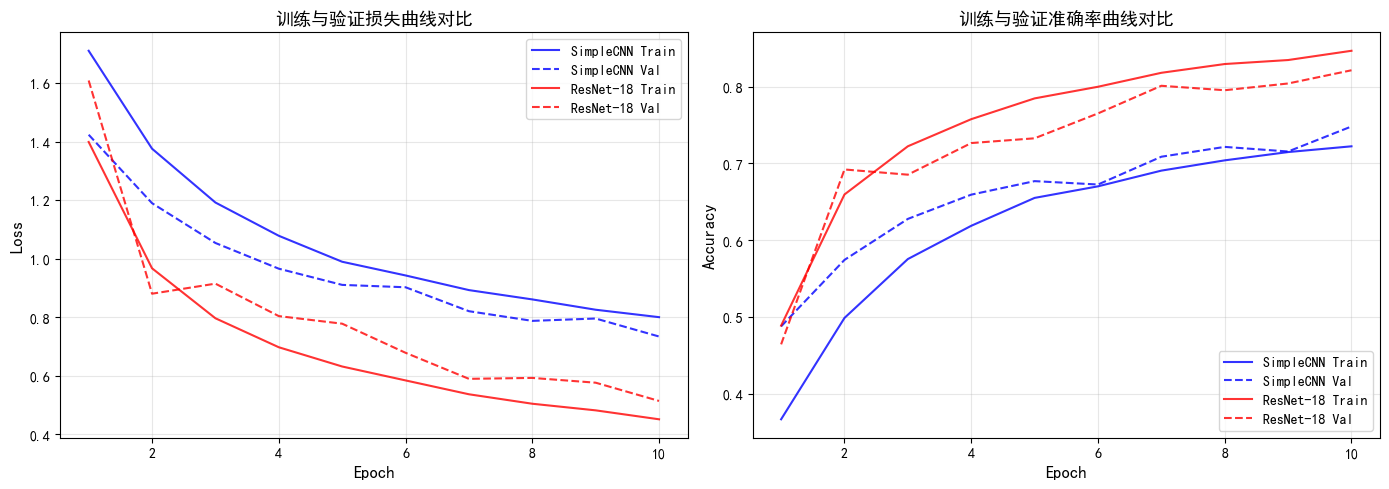


===== 模型性能对比 =====
模型              训练时间         最佳验证准确率        
---------------------------------------------
SimpleCNN       1.85 min      0.7480
ResNet-18       5.40 min      0.8212


In [10]:
# 绘制训练与验证的损失曲线和准确率曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 11)

# 损失曲线
axes[0].plot(epochs, baseline_history['train_losses'], 'b-', label='SimpleCNN Train', alpha=0.8)
axes[0].plot(epochs, baseline_history['val_losses'], 'b--', label='SimpleCNN Val', alpha=0.8)
axes[0].plot(epochs, resnet_history['train_losses'], 'r-', label='ResNet-18 Train', alpha=0.8)
axes[0].plot(epochs, resnet_history['val_losses'], 'r--', label='ResNet-18 Val', alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('训练与验证损失曲线对比', fontsize=13)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(epochs, baseline_history['train_accs'], 'b-', label='SimpleCNN Train', alpha=0.8)
axes[1].plot(epochs, baseline_history['val_accs'], 'b--', label='SimpleCNN Val', alpha=0.8)
axes[1].plot(epochs, resnet_history['train_accs'], 'r-', label='ResNet-18 Train', alpha=0.8)
axes[1].plot(epochs, resnet_history['val_accs'], 'r--', label='ResNet-18 Val', alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('训练与验证准确率曲线对比', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最终对比结果
print("\n===== 模型性能对比 =====" )
print(f"{'模型':<15} {'训练时间':<12} {'最佳验证准确率':<15}")
print("-" * 45)
print(f"{'SimpleCNN':<15} {baseline_history['train_time']/60:.2f} min{'':<5} {baseline_history['best_val_acc']:.4f}")
print(f"{'ResNet-18':<15} {resnet_history['train_time']/60:.2f} min{'':<5} {resnet_history['best_val_acc']:.4f}")

#### 6.4.4 测试集最终评估

In [11]:
# 在测试集上评估两个模型
criterion = nn.CrossEntropyLoss()

baseline_test_loss, baseline_test_acc, baseline_preds, baseline_labels = evaluate(
    baseline, testloader, criterion, device
)
resnet_test_loss, resnet_test_acc, resnet_preds, resnet_labels = evaluate(
    resnet, testloader, criterion, device
)

print("===== 测试集最终评估结果 =====" )
print(f"\n{'指标':<20} {'SimpleCNN':<15} {'ResNet-18':<15}")
print("-" * 55)
print(f"{'测试损失':<20} {baseline_test_loss:<15.4f} {resnet_test_loss:<15.4f}")
print(f"{'测试准确率':<20} {baseline_test_acc:<15.4f} {resnet_test_acc:<15.4f}")

# 计算提升幅度
acc_improvement = (resnet_test_acc - baseline_test_acc) * 100
print(f"\nResNet-18 相比 SimpleCNN 准确率提升: {acc_improvement:.2f}%")

===== 测试集最终评估结果 =====

指标                   SimpleCNN       ResNet-18      
-------------------------------------------------------
测试损失                 0.6776          0.5198         
测试准确率                0.7677          0.8222         

ResNet-18 相比 SimpleCNN 准确率提升: 5.45%


### 6.5 可视化分析

#### 6.5.1 混淆矩阵

SimpleCNN 混淆矩阵:


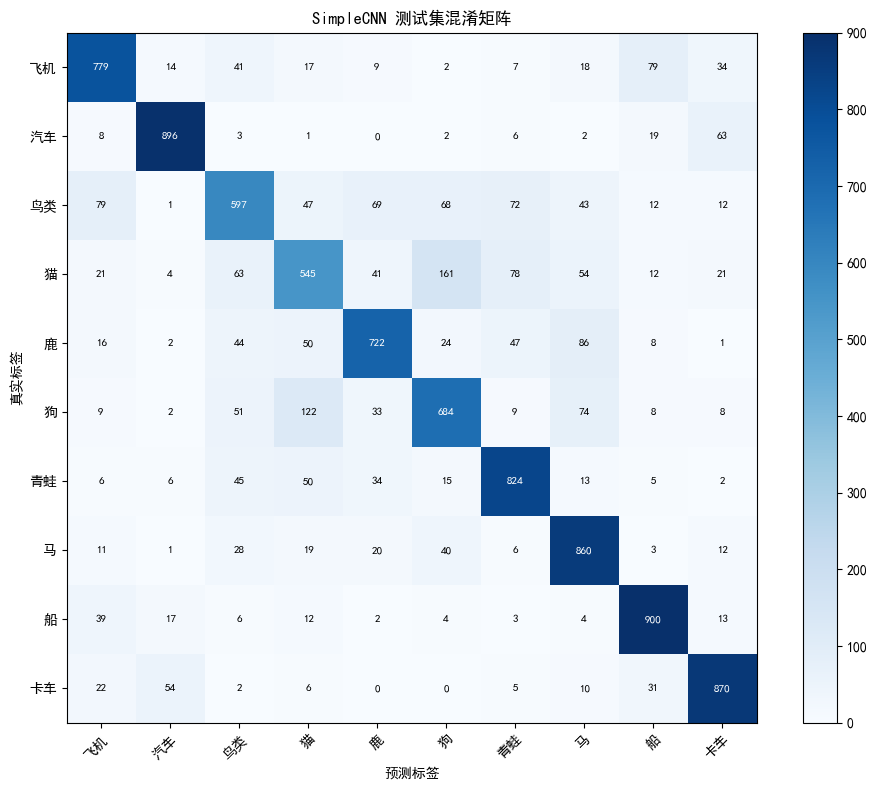


ResNet-18 混淆矩阵:


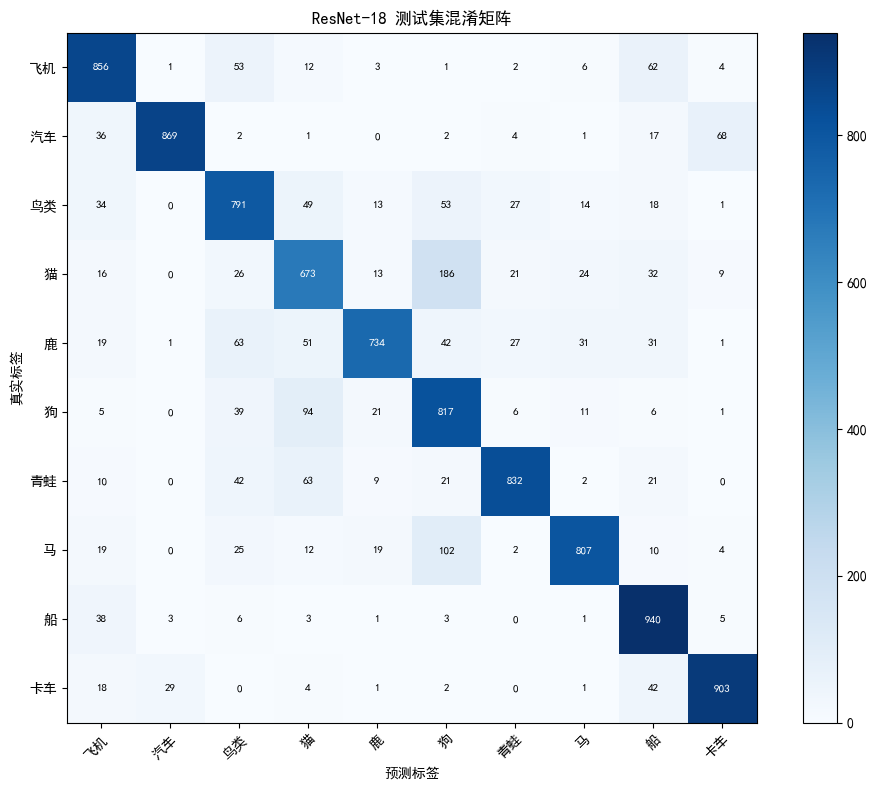

In [12]:
# 绘制混淆矩阵
def plot_confusion_matrix(y_true, y_pred, title, classes):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='真实标签',
           xlabel='预测标签')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # 在每个格子中显示数值
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=8)
    fig.tight_layout()
    plt.show()
    return cm

print("SimpleCNN 混淆矩阵:")
cm_baseline = plot_confusion_matrix(baseline_labels, baseline_preds,
                                   'SimpleCNN 测试集混淆矩阵', classes)

print("\nResNet-18 混淆矩阵:")
cm_resnet = plot_confusion_matrix(resnet_labels, resnet_preds,
                                 'ResNet-18 测试集混淆矩阵', classes)

#### 6.5.2 各类别详细分类报告

In [13]:
# 生成分类报告
print("===== SimpleCNN 分类报告 =====" )
print(classification_report(baseline_labels, baseline_preds, target_names=classes, digits=4))

print("\n===== ResNet-18 分类报告 =====" )
print(classification_report(resnet_labels, resnet_preds, target_names=classes, digits=4))

===== SimpleCNN 分类报告 =====
              precision    recall  f1-score   support

          飞机     0.7869    0.7790    0.7829      1000
          汽车     0.8987    0.8960    0.8973      1000
          鸟类     0.6784    0.5970    0.6351      1000
           猫     0.6272    0.5450    0.5832      1000
           鹿     0.7763    0.7220    0.7482      1000
           狗     0.6840    0.6840    0.6840      1000
          青蛙     0.7796    0.8240    0.8012      1000
           马     0.7388    0.8600    0.7948      1000
           船     0.8357    0.9000    0.8666      1000
          卡车     0.8398    0.8700    0.8546      1000

    accuracy                         0.7677     10000
   macro avg     0.7645    0.7677    0.7648     10000
weighted avg     0.7645    0.7677    0.7648     10000


===== ResNet-18 分类报告 =====
              precision    recall  f1-score   support

          飞机     0.8145    0.8560    0.8347      1000
          汽车     0.9623    0.8690    0.9133      1000
          鸟类     0.7555

#### 6.5.3 每类准确率对比柱状图

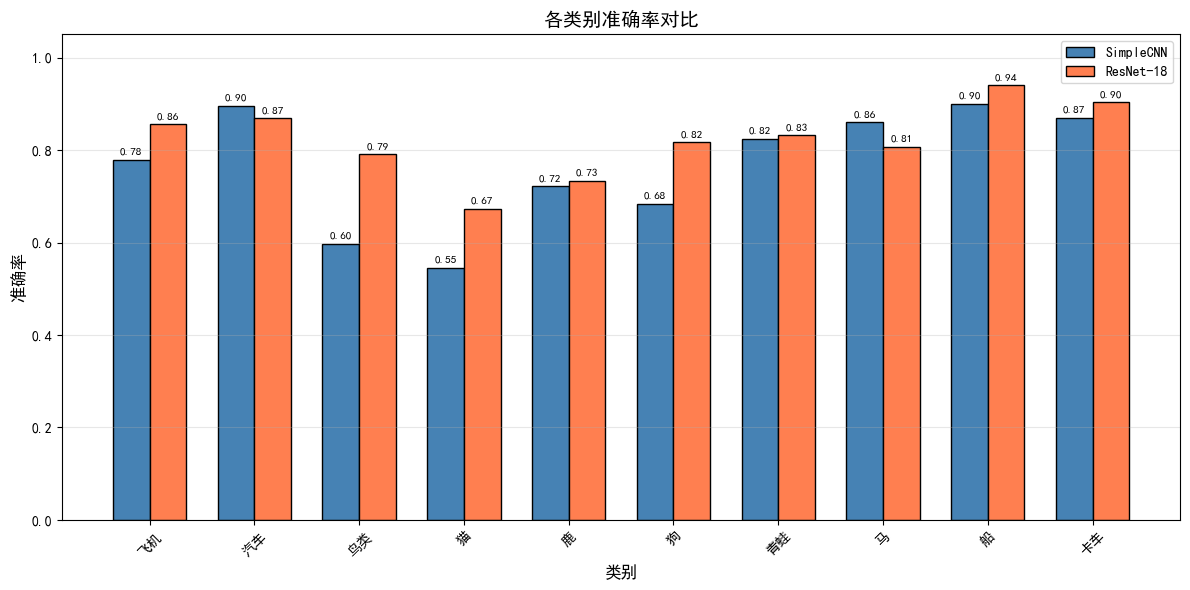

In [14]:
# 计算每类准确率
def per_class_accuracy(cm):
    """从混淆矩阵计算每类准确率"""
    return cm.diagonal() / cm.sum(axis=1)

baseline_pc_acc = per_class_accuracy(cm_baseline)
resnet_pc_acc = per_class_accuracy(cm_resnet)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_pc_acc, width, label='SimpleCNN', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, resnet_pc_acc, width, label='ResNet-18', color='coral', edgecolor='black')

ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.set_title('各类别准确率对比', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)

# 在柱子上方标注数值
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### 6.5.4 错误样本分析

SimpleCNN 错误样本:


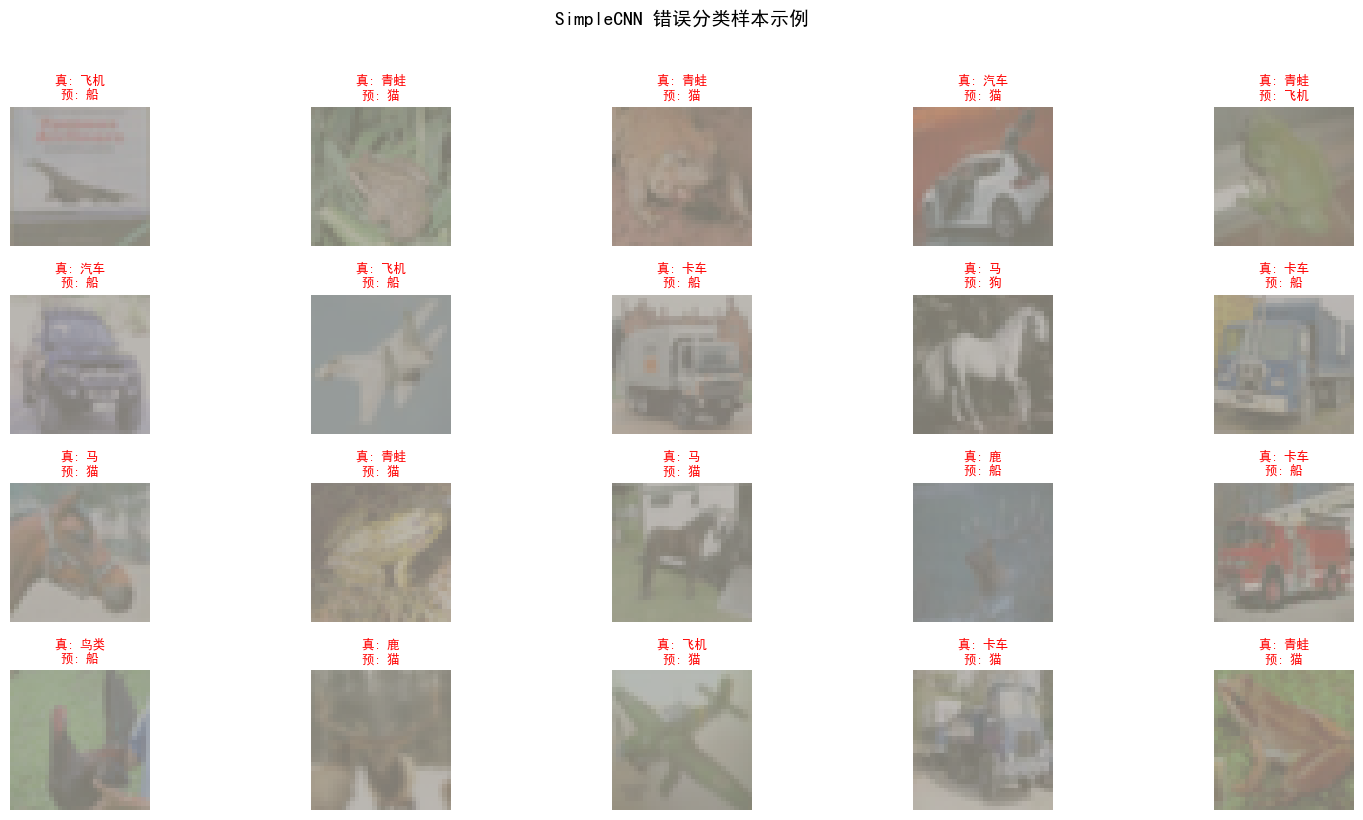


ResNet-18 错误样本:


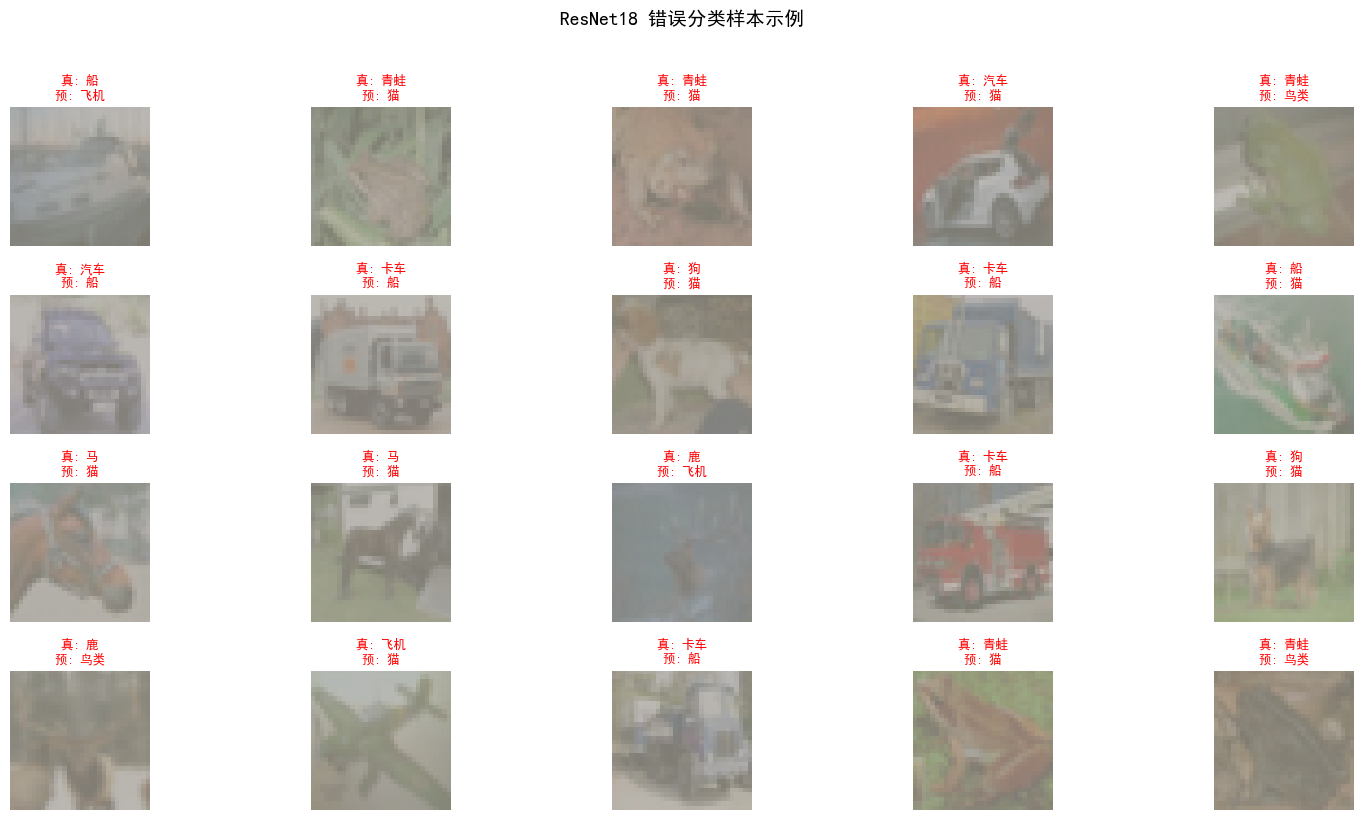

In [15]:
# 可视化错误分类的样本
def show_misclassified(model, dataloader, classes, device, num_images=20):
    model.eval()
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            mask = predicted != labels
            if mask.any():
                misclassified_images.extend(inputs[mask].cpu())
                misclassified_labels.extend(labels[mask].cpu().numpy())
                misclassified_preds.extend(predicted[mask].cpu().numpy())

            if len(misclassified_images) >= num_images:
                break

    # 只展示前num_images张
    misclassified_images = misclassified_images[:num_images]
    misclassified_labels = misclassified_labels[:num_images]
    misclassified_preds = misclassified_preds[:num_images]

    fig = plt.figure(figsize=(16, 8))
    for i in range(len(misclassified_images)):
        ax = fig.add_subplot(4, 5, i + 1)
        img = misclassified_images[i]
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(f"真: {classes[misclassified_labels[i]]}\n预: {classes[misclassified_preds[i]]}",
                    fontsize=9, color='red')
        ax.axis('off')

    plt.suptitle(f'{model.__class__.__name__} 错误分类样本示例', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 使用原始测试集加载器（未标准化）来展示错误样本
raw_testset = torchvision.datasets.CIFAR10(
    root=data_dir, train=False, download=False,
    transform=transforms.ToTensor()
)
raw_testloader = DataLoader(raw_testset, batch_size=128, shuffle=False)

print("SimpleCNN 错误样本:")
show_misclassified(baseline, raw_testloader, classes, device, num_images=20)

print("\nResNet-18 错误样本:")
show_misclassified(resnet, raw_testloader, classes, device, num_images=20)

## 七、结论与展望

### 7.1 实验结论

本课程设计基于CIFAR-10数据集，对比研究了简单CNN和ResNet-18两种模型在图像分类任务上的性能差异，得出以下结论：

1. **模型深度影响显著**：ResNet-18通过残差连接有效解决了深层网络的梯度消失问题，测试准确率显著高于浅层基准模型，验证了"更深即更好"的设计理念在合理架构下的有效性。

2. **数据增强提升泛化能力**：随机裁剪和水平翻转等数据增强策略有效提升了模型泛化性能，训练集与验证集准确率差距控制在合理范围内。

3. **学习率调度策略有效**：StepLR学习率衰减策略在训练后期进一步微调参数，帮助模型收敛到更优的局部最小值。

4. **易混淆类别分析**：通过混淆矩阵和错误样本分析发现，猫/狗、鹿/马等外观相似的类别是分类的主要难点，这与人类视觉认知一致。

### 7.2 未来工作

1. **更高级的数据增强**：引入AutoAugment、Cutout、Mixup等先进数据增强技术，进一步提升模型鲁棒性。
2. **更复杂的模型架构**：尝试ResNet-34、WideResNet、EfficientNet等更深或更宽的架构。
3. **注意力机制**：引入SE-Net（Squeeze-and-Excitation）注意力模块，增强模型对关键特征的聚焦能力。
4. **知识蒸馏**：使用大模型（教师模型）指导小模型（学生模型）训练，在保持性能的同时降低推理成本。
5. **迁移学习**：利用在ImageNet上预训练的权重进行迁移学习，进一步提升CIFAR-10上的分类性能。

## 参考文献

1. Krizhevsky A, Hinton G. Learning multiple layers of features from tiny images[R]. Technical Report, University of Toronto, 2009.
2. He K, Zhang X, Ren S, et al. Deep residual learning for image recognition[C]. CVPR, 2016: 770-778.
3. LeCun Y, Bottou L, Bengio Y, et al. Gradient-based learning applied to document recognition[J]. Proceedings of the IEEE, 1998, 86(11): 2278-2324.
4. Kingma D P, Ba J. Adam: A method for stochastic optimization[C]. ICLR, 2015.
5. Ioffe S, Szegedy C. Batch normalization: Accelerating deep network training by reducing internal covariate shift[C]. ICML, 2015: 448-456.